# Environmental Impact Analysis

Three models, three purposes:
1. Deforestation detection from satellite tiles (MobileNetV2, transfer learning)
2. PM2.5 forecasting from CPCB pollutant history (lag features, XGBoost/NN)
3. Satellite + air quality fusion — NDVI joined to PM2.5 by city/date, tested via ablation

Pipelines 1 and 3 use satellite imagery; only 3 actually combines it with air quality data.
Pipeline 3 runs on a different dataset than Pipeline 2 (29 cities, 2022-2025) since that's
the only one with real coordinates.

Limitations that matter for interpreting the results:
- NH3 is missing entirely from the fusion dataset, dropped from features
- NDVI pulled for 300 of ~35k possible (city, date) pairs — Earth Engine rate limits at scale
- The composite index in Section 5 is almost entirely driven by pollution, not vegetation


## Setup

In [1]:
!pip install -q tensorflow scikit-learn pandas numpy matplotlib seaborn kaggle xgboost earthengine-api


In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models
from PIL import Image
from xgboost import XGBRegressor

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from google.colab import files
uploaded = files.upload();   # <- semicolon suppresses auto-display of the returned dict

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle credentials installed (not printed).")


Saving kaggle.json to kaggle.json
Kaggle credentials installed (not printed).


In [4]:
!kaggle datasets download -d prosperchuks/amazonsatelliteimages -q
!unzip -q -o amazonsatelliteimages.zip

!kaggle datasets download -d abhisheksjha/time-series-air-quality-data-of-india-2010-2023 -q
!unzip -q -o time-series-air-quality-data-of-india-2010-2023.zip -d air_quality_data

!kaggle datasets download -d bhautikvekariya21/air-quality-dataset-indian-cities-2022-2025 -q
!unzip -q -o air-quality-dataset-indian-cities-2022-2025.zip -d air_quality_geo_data


Dataset URL: https://www.kaggle.com/datasets/prosperchuks/amazonsatelliteimages
License(s): unknown
Dataset URL: https://www.kaggle.com/datasets/abhisheksjha/time-series-air-quality-data-of-india-2010-2023
License(s): CC-BY-NC-SA-4.0
Dataset URL: https://www.kaggle.com/datasets/bhautikvekariya21/air-quality-dataset-indian-cities-2022-2025
License(s): CC-BY-NC-SA-4.0


In [ ]:
import ee
ee.Authenticate(auth_mode='notebook')  # follow the printed link, paste the verification code


In [7]:
ee.Initialize(project='environmentalanalysismodel')  # swap in your own GCP project id
print("EE initialized")


EE initialized


## 1. Deforestation detection

In [8]:
base_dir = '/content'
labels_path = os.path.join(base_dir, 'train_v2.csv', 'train_v2.csv')
labels_df = pd.read_csv(labels_path)

labels_df['deforestation'] = labels_df['tags'].apply(
    lambda x: 1 if ('habitation' in x or 'slash_burn' in x) else 0
)
labels_df['image_name'] = labels_df['image_name'].apply(lambda x: f"{x}.jpg")

class_counts = labels_df['deforestation'].value_counts(normalize=True)
print(class_counts)
majority_baseline_acc = class_counts.max()
print(f"Majority-class baseline accuracy: {majority_baseline_acc:.4f}")


deforestation
0    0.905432
1    0.094568
Name: proportion, dtype: float64
Majority-class baseline accuracy: 0.9054


In [9]:
train_df, temp_df = train_test_split(
    labels_df, test_size=0.30, stratify=labels_df['deforestation'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['deforestation'], random_state=SEED
)
print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")


train=28335  val=6072  test=6072


In [10]:
# IMPORTANT: these JPEGs are CMYK-encoded, not standard RGB. tf.io.decode_jpeg silently
# produces all-zero images for CMYK JPEGs instead of raising an error — this was the root
# cause of a completely dead network (val_auc stuck at 0.5) earlier today. Loading through
# PIL (which handles CMYK correctly) inside tf.py_function fixes it.

IMG_SIZE = 128
BATCH_SIZE = 64
train_dir = os.path.join(base_dir, 'train-jpg', 'train-jpg')

def _load_with_pil(path_tensor, label_tensor):
    path = path_tensor.numpy().decode('utf-8')
    img = Image.open(path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))  # .convert('RGB') fixes CMYK
    img = np.array(img).astype('float32') / 255.0
    return img, label_tensor.numpy()

def make_dataset(df, directory, img_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False):
    df = df[df['image_name'].apply(lambda x: os.path.exists(os.path.join(directory, x)))]
    paths = df['image_name'].apply(lambda x: os.path.join(directory, x)).values
    labels = df['deforestation'].values

    def _load(path, label):
        img, lbl = tf.py_function(func=_load_with_pil, inp=[path, label], Tout=[tf.float32, tf.int64])
        img.set_shape([img_size, img_size, 3])
        lbl.set_shape([])
        return img, lbl

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds, labels

train_ds, y_train = make_dataset(train_df, train_dir, shuffle=True)
val_ds, y_val = make_dataset(val_df, train_dir)
test_ds, y_test = make_dataset(test_df, train_dir)
print("Datasets built using PIL-based loading (CMYK-safe).")


Datasets built using PIL-based loading (CMYK-safe).


In [11]:
IMG_SIZE = 128
BATCH_SIZE = 64
train_dir = os.path.join(base_dir, 'train-jpg', 'train-jpg')

# these jpegs are CMYK, not RGB. tf.io.decode_jpeg reads them as all-zero instead of
# throwing an error, so loading through PIL instead (.convert('RGB') handles the conversion)
def _load_with_pil(path_tensor, label_tensor):
    path = path_tensor.numpy().decode('utf-8')
    img = Image.open(path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img).astype('float32') / 255.0
    return img, label_tensor.numpy()

def make_dataset(df, directory, img_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False):
    df = df[df['image_name'].apply(lambda x: os.path.exists(os.path.join(directory, x)))]
    paths = df['image_name'].apply(lambda x: os.path.join(directory, x)).values
    labels = df['deforestation'].values

    def _load(path, label):
        img, lbl = tf.py_function(func=_load_with_pil, inp=[path, label], Tout=[tf.float32, tf.int64])
        img.set_shape([img_size, img_size, 3])
        lbl.set_shape([])
        return img, lbl

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds, labels

train_ds, y_train = make_dataset(train_df, train_dir, shuffle=True)
val_ds, y_val = make_dataset(val_df, train_dir)
test_ds, y_test = make_dataset(test_df, train_dir)


pixel range: 0.003921568859368563 - 0.9882352948188782


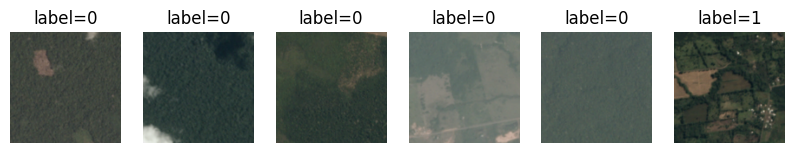

In [12]:
for images, labels in train_ds.take(1):
    print("pixel range:", float(tf.reduce_min(images)), "-", float(tf.reduce_max(images)))
    plt.figure(figsize=(10, 4))
    for i in range(6):
        plt.subplot(1, 6, i+1)
        plt.imshow(images[i].numpy())
        plt.title(f"label={labels[i].numpy()}")
        plt.axis('off')
    plt.show()


In [13]:
baseline = DummyClassifier(strategy='most_frequent', random_state=SEED)
baseline.fit(np.zeros((len(y_train), 1)), y_train)
baseline_preds = baseline.predict(np.zeros((len(y_val), 1)))
print(classification_report(y_val, baseline_preds, zero_division=0))


              precision    recall  f1-score   support

           0       0.91      1.00      0.95      5498
           1       0.00      0.00      0.00       574

    accuracy                           0.91      6072
   macro avg       0.45      0.50      0.48      6072
weighted avg       0.82      0.91      0.86      6072



In [14]:
# from-scratch CNN got stuck at val_auc 0.5 even after fixing the CMYK bug -
# not enough signal in ~30k images w/ 9.5% positive rate for a model trained from zero.
# frozen MobileNetV2 + small head works a lot better

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: 1.0, 1: min(class_weights[1], 3.0)}  # raw balanced ratio was unstable
print("class weights:", class_weight_dict)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomBrightness(0.1),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False

image_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(image_input)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

satellite_model = models.Model(inputs=image_input, outputs=output)
satellite_model.compile(
    optimizer='adam', loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True)

history = satellite_model.fit(
    train_ds, validation_data=val_ds, epochs=25,
    class_weight=class_weight_dict, callbacks=[early_stop]
)


class weights: {0: 1.0, 1: 3.0}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/25
443/443 ━━━━━━━━━━━━━━━━━━━━ 144s 300ms/step - accuracy: 0.8955 - auc: 0.5823 - loss: 0.6573 - val_accuracy: 0.8483 - val_auc: 0.8776 - val_loss: 0.3188
Epoch 2/25
443/443 ━━━━━━━━━━━━━━━━━━━━ 128s 290ms/step - accuracy: 0.8975 - auc: 0.6611 - loss: 0.6135 - val_accuracy: 0.8883 - val_auc: 0.8813 - val_loss: 0.2751
Epoch 3/25
443/443 ━━━━━━━━━━━━━━━━━━━━ 126s 286ms/step - accuracy: 0.8961 - auc: 0.6708 - loss: 0.6084 - val_accuracy: 0.8974 - val_auc: 0.9023 - val_loss: 0.2828
Epoch 4/25
443/443 ━━━━━━━━━━━━━━━━━━━━ 127s 288ms/step - accuracy: 0.8975 - auc: 0.6879 - loss: 0.5987 - val_accuracy: 0.8669 - val_auc: 0.9036 - val_loss: 0.2900
Epoch 5/25
443/443 ━━━━━━━━━━━━━━━━━━━━ 128s 290ms/step - accuracy: 0.8987 - auc: 0.6899 - loss: 0.5941 - val_accuracy: 0.8997 - val_auc: 0.9005 - val_loss: 0.2406
Epoch 6/25
443/443 ━━━━━━━━━━━━━━━━━━━━ 145s 328ms/step - accuracy: 0.8973 - auc: 0.6971 - loss: 0.

In [15]:
from google.colab import drive
drive.mount('/content/drive')
satellite_model.save('/content/drive/MyDrive/deforestation_model.keras')


Mounted at /content/drive


Test set eval — the numbers that actually matter, not train/val.

95/95 ━━━━━━━━━━━━━━━━━━━━ 27s 263ms/step
              precision    recall  f1-score   support

           0       0.97      0.92      0.94      5498
           1       0.46      0.69      0.55       574

    accuracy                           0.89      6072
   macro avg       0.71      0.80      0.75      6072
weighted avg       0.92      0.89      0.90      6072

ROC-AUC: 0.9188593127941361


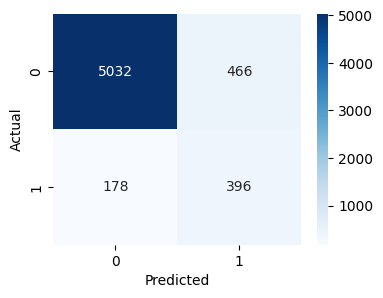

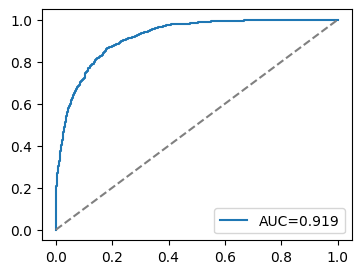

baseline acc: 0.9054, model acc: 0.8939


In [16]:
test_probs = satellite_model.predict(test_ds).flatten()
test_preds = (test_probs >= 0.5).astype(int)

print(classification_report(y_test, test_preds, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))

cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

fpr, tpr, _ = roc_curve(y_test, test_probs)
plt.figure(figsize=(4, 3))
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test, test_probs):.3f}")
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.legend(); plt.show()

print(f"baseline acc: {majority_baseline_acc:.4f}, model acc: {accuracy_score(y_test, test_preds):.4f}")


Threshold isn't fixed at 0.5 by necessity — trade precision for recall depending on what matters more here.

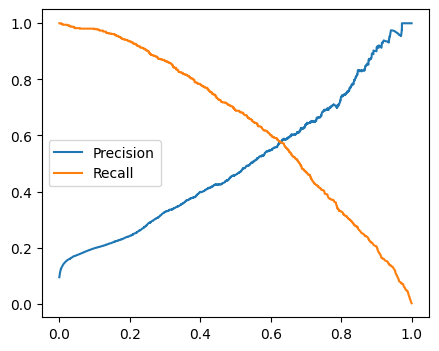

              precision    recall  f1-score   support

           0       0.98      0.81      0.89      5498
           1       0.33      0.87      0.48       574

    accuracy                           0.82      6072
   macro avg       0.66      0.84      0.68      6072
weighted avg       0.92      0.82      0.85      6072



In [17]:
precisions, recalls, thresholds = precision_recall_curve(y_test, test_probs)
plt.figure(figsize=(5, 4))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.legend(); plt.show()

test_preds_lower = (test_probs >= 0.3).astype(int)
print(classification_report(y_test, test_preds_lower, zero_division=0))


In [19]:
air_quality_data_dir = "/content/air_quality_data"
air_quality_files = [
    os.path.join(air_quality_data_dir, f)
    for f in os.listdir(air_quality_data_dir)
    if f.endswith(".csv") and f != "stations_info.csv"
]

target_cols = ["From Date", "To Date", "PM2.5 (ug/m3)", "PM10 (ug/m3)", "NO (ug/m3)",
               "NO2 (ug/m3)", "NOx (ppb)", "NH3 (ug/m3)", "SO2 (ug/m3)", "CO (mg/m3)"]

combined_chunks = []
columns_missing_log = {}
for f in air_quality_files:
    try:
        available = pd.read_csv(f, nrows=0).columns.tolist()
        cols_here = [c for c in target_cols if c in available]
        missing = [c for c in target_cols if c not in available]
        if missing:
            columns_missing_log[os.path.basename(f)] = missing

        dtype_map = {c: "float32" for c in cols_here if "Date" not in c}
        df = pd.read_csv(f, usecols=cols_here, dtype=dtype_map)
        df["__source_file"] = os.path.basename(f)
        combined_chunks.append(df)
    except Exception as e:
        print(f"Skipping {f} entirely: {e}")

combined_df = pd.concat(combined_chunks, ignore_index=True, copy=False)
del combined_chunks
import gc; gc.collect()

combined_df["__source_file"] = combined_df["__source_file"].astype("category")

print("stations loaded:", combined_df["__source_file"].nunique(), "/", len(air_quality_files))
print("stations missing a pollutant:", len(columns_missing_log))
print(combined_df.shape)
print(f"memory: {combined_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

date_candidates = [c for c in combined_df.columns if "date" in c.lower() or "time" in c.lower()]
print("possible date columns:", date_candidates)

stations loaded: 453 / 453
stations missing a pollutant: 94
(14295663, 11)
memory: 2.43 GB
possible date columns: ['From Date', 'To Date']


In [23]:
DATE_COL = date_candidates[0] if date_candidates else None

if DATE_COL:
    combined_df[DATE_COL] = pd.to_datetime(combined_df[DATE_COL], errors='coerce')
    combined_df = combined_df.dropna(subset=[DATE_COL]).sort_values(DATE_COL)
    print(f"Using '{DATE_COL}' as the time axis. Rows with valid dates: {len(combined_df)}")
else:
    print("No usable date column found — treating this as same-timestamp regression.")

Using 'From Date' as the time axis. Rows with valid dates: 14295663


Rows after dropping missing essentials: 5740652


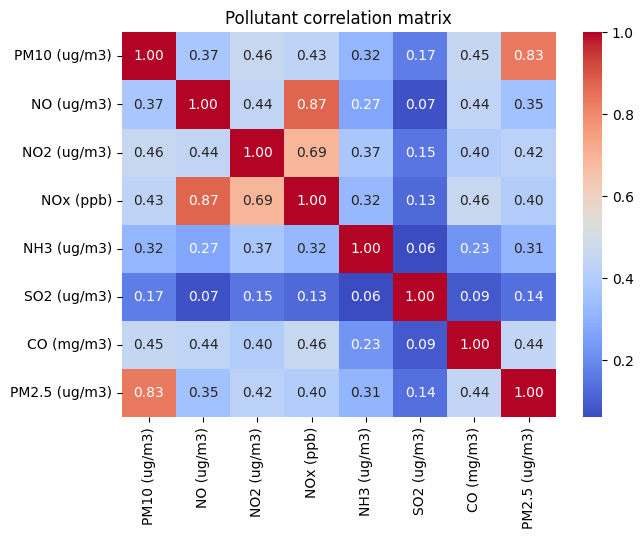

In [20]:
essential_cols = [
    'PM10 (ug/m3)', 'NO (ug/m3)', 'NO2 (ug/m3)', 'NOx (ppb)',
    'NH3 (ug/m3)', 'SO2 (ug/m3)', 'CO (mg/m3)', 'PM2.5 (ug/m3)'
]
essential_cols = [c for c in essential_cols if c in combined_df.columns]
combined_df_cleaned = combined_df.dropna(subset=essential_cols).copy()
print(f"Rows after dropping missing essentials: {len(combined_df_cleaned)}")

plt.figure(figsize=(7, 5))
sns.heatmap(combined_df_cleaned[essential_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Pollutant correlation matrix')
plt.show()


In [25]:
target = 'PM2.5 (ug/m3)'
other_pollutant_cols = [c for c in essential_cols if c != target]

if DATE_COL:
    group_col = '__source_file'
    df_fe = combined_df_cleaned.sort_values([group_col, DATE_COL]).copy()
    df_fe[DATE_COL] = pd.to_datetime(df_fe[DATE_COL], errors='coerce')  # force it here, don't assume it stuck from an earlier cell
    df_fe = df_fe.dropna(subset=[DATE_COL])

    lagged_feature_cols = []
    for col in [target] + other_pollutant_cols:
        for lag in [1, 2, 3]:
            colname = f'{col}_lag{lag}'
            df_fe[colname] = df_fe.groupby(group_col, observed=True)[col].shift(lag)
            lagged_feature_cols.append(colname)
        roll_name = f'{col}_roll3'
        df_fe[roll_name] = (
            df_fe.groupby(group_col, observed=True)[col].shift(1).rolling(3).mean().reset_index(0, drop=True)
        )
        lagged_feature_cols.append(roll_name)

    df_fe = df_fe.dropna(subset=lagged_feature_cols)
    feature_cols_fe = lagged_feature_cols

    cutoff = df_fe[DATE_COL].quantile(0.8)
    train_fe = df_fe[df_fe[DATE_COL] <= cutoff]
    test_fe = df_fe[df_fe[DATE_COL] > cutoff]

    X_train_reg = train_fe[feature_cols_fe].values
    y_train_reg = train_fe[target].values
    X_val_reg = test_fe[feature_cols_fe].values
    y_val_reg = test_fe[target].values

    print(f"Forecasting setup — {len(lagged_feature_cols)} lag/rolling features")
    print(f"train: {len(train_fe)}, test: {len(test_fe)} (split at {cutoff.date()})")
else:
    feature_cols = other_pollutant_cols
    X = combined_df_cleaned[feature_cols].values
    y = combined_df_cleaned[target].values
    X_train_reg, X_val_reg, y_train_reg, y_val_reg = train_test_split(X, y, test_size=0.2, random_state=SEED)
    print("Regression setup (no timestamps) — NOT forecasting, label it as regression.")

Forecasting setup — 32 lag/rolling features
train: 2107846, test: 526935 (split at 2022-09-01)


In [26]:
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_reg, y_train_reg)
dummy_preds = dummy.predict(X_val_reg)
baseline_mae = mean_absolute_error(y_val_reg, dummy_preds)
baseline_rmse = np.sqrt(mean_squared_error(y_val_reg, dummy_preds))
print(f"Baseline (predict the mean) — MAE: {baseline_mae:.2f}, RMSE: {baseline_rmse:.2f}")


Baseline (predict the mean) — MAE: 42.23, RMSE: 63.53


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [03:55:28] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


XGBoost (GPU) — MAE: 9.17, RMSE: 19.85, R2: 0.901


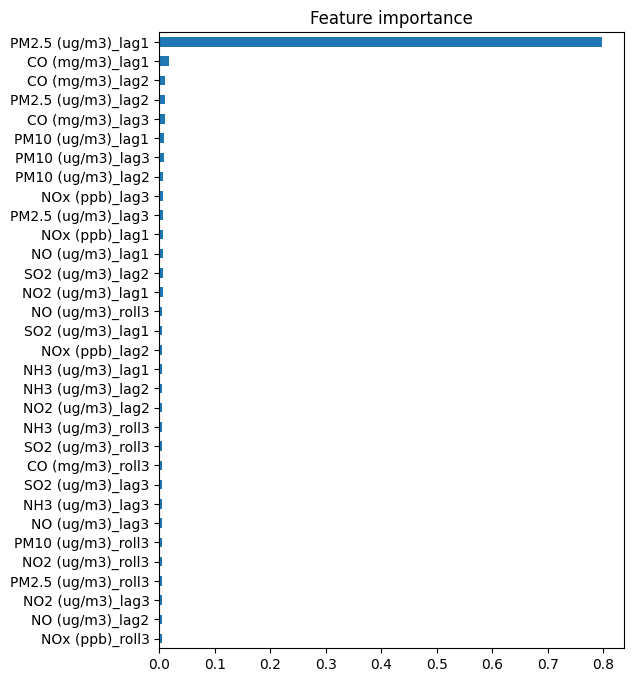

In [27]:
# switched from sklearn RF to XGBoost here - RF on 1.7M+ rows was taking 20+ min even
# with depth capped, XGBoost w/ tree_method='hist', device='cuda' does it in ~1-2 min.
# this is gradient boosting not bagging, different algo than RF
xgb_model = XGBRegressor(
    n_estimators=300, max_depth=8, tree_method='hist', device='cuda', random_state=SEED
)
xgb_model.fit(X_train_reg, y_train_reg)
xgb_preds = xgb_model.predict(X_val_reg)

xgb_mae = mean_absolute_error(y_val_reg, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_val_reg, xgb_preds))
xgb_r2 = r2_score(y_val_reg, xgb_preds)
print(f"XGBoost (GPU) — MAE: {xgb_mae:.2f}, RMSE: {xgb_rmse:.2f}, R2: {xgb_r2:.3f}")

importances = pd.Series(xgb_model.feature_importances_, index=feature_cols_fe if DATE_COL else feature_cols)
importances.sort_values().plot(kind='barh', figsize=(6, 8), title='Feature importance')
plt.show()


In [28]:
nn_input = layers.Input(shape=(X_train_reg.shape[1],))
x = layers.Dense(64, activation='relu')(nn_input)
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.3)(x)
nn_output = layers.Dense(1, activation='linear')(x)

air_quality_model = models.Model(inputs=nn_input, outputs=nn_output)
air_quality_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop_reg = tf.keras.callbacks.EarlyStopping(monitor='val_mae', patience=5, restore_best_weights=True)

hist_nn = air_quality_model.fit(
    X_train_reg, y_train_reg, validation_data=(X_val_reg, y_val_reg),
    epochs=100, batch_size=4096,   # large batch — GPU-appropriate, not the default 32
    callbacks=[early_stop_reg], verbose=1
)

nn_preds = air_quality_model.predict(X_val_reg).flatten()
nn_mae = mean_absolute_error(y_val_reg, nn_preds)
nn_rmse = np.sqrt(mean_squared_error(y_val_reg, nn_preds))
nn_r2 = r2_score(y_val_reg, nn_preds)
print(f"Neural net — MAE: {nn_mae:.2f}, RMSE: {nn_rmse:.2f}, R2: {nn_r2:.3f}")


Epoch 1/100
515/515 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 1802.9459 - mae: 22.9412 - val_loss: 712.3812 - val_mae: 16.5012
Epoch 2/100
515/515 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 812.3664 - mae: 15.5953 - val_loss: 551.3105 - val_mae: 13.2683
Epoch 3/100
515/515 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 752.1464 - mae: 14.7188 - val_loss: 506.4370 - val_mae: 12.2374
Epoch 4/100
515/515 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 723.5839 - mae: 14.2825 - val_loss: 501.3910 - val_mae: 12.0195
Epoch 5/100
515/515 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 708.9746 - mae: 13.9908 - val_loss: 452.7226 - val_mae: 10.9011
Epoch 6/100
515/515 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 691.7228 - mae: 13.7379 - val_loss: 479.7741 - val_mae: 11.5668
Epoch 7/100
515/515 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 672.6105 - mae: 13.4796 - val_loss: 508.1570 - val_mae: 12.2248
Epoch 8/100
515/515 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 655.9975 - mae: 13.2073 - val_loss: 485.5681 - val_mae: 11.7079

In [29]:
results = pd.DataFrame({
    'model': ['Baseline (mean)', 'XGBoost', 'Neural Net'],
    'MAE': [baseline_mae, xgb_mae, nn_mae],
    'RMSE': [baseline_rmse, xgb_rmse, nn_rmse],
    'R2': [0.0, xgb_r2, nn_r2],
})
print(results.to_string(index=False))


          model       MAE      RMSE       R2
Baseline (mean) 42.225147 63.530891 0.000000
        XGBoost  9.170812 19.854975 0.901386
     Neural Net 10.901080 21.277282 0.886752


## 3. Fusion: satellite NDVI + PM2.5

Different dataset than Pipeline 2 (bhautikvekariya21, 29 cities, 2022-2025) because it has
real lat/lon and the CPCB dataset doesn't. Point-in-time, not lag-based - Sentinel-2 has real
monsoon cloud gaps that break a continuous lag setup.

NDVI pulled for a 300-pair sample, not the full ~35k - each Earth Engine call is a network
round trip, full scale would take 20+ hrs. Real version of this would use
ee.batch.Export.table.toDrive() and pull results async.

In [30]:
geo_dir = '/content/air_quality_geo_data'
geo_files = [os.path.join(geo_dir, f) for f in os.listdir(geo_dir) if f.endswith('.csv')]
geo_df = pd.concat([pd.read_csv(f) for f in geo_files], ignore_index=True)

geo_df['Datetime'] = pd.to_datetime(geo_df['Datetime'], errors='coerce')
geo_df = geo_df.dropna(subset=['Datetime', 'Latitude', 'Longitude', 'PM2_5_ugm3'])
geo_df['date_only'] = geo_df['Datetime'].dt.date

print(geo_df[['City', 'Latitude', 'Longitude']].drop_duplicates().shape[0], "unique cities")
print(geo_df['Datetime'].min(), "to", geo_df['Datetime'].max())


29 unique cities
2022-08-05 00:00:00 to 2025-11-26 23:00:00


In [31]:
city_coords = geo_df[['City', 'Latitude', 'Longitude']].drop_duplicates().reset_index(drop=True)
city_date_pairs = geo_df[['City', 'date_only']].drop_duplicates().merge(city_coords, on='City')
print(f"{len(city_date_pairs)} unique (city, date) pairs found")


35090 unique (city, date) pairs found


In [33]:
import ee
try:
    ee.Initialize(project='environmentalanalysismodel')
    print("EE initialized OK")
except Exception as e:
    print("Init failed:", e)

EE initialized OK


In [36]:
def get_ndvi_for_point(lat, lon, date, buffer_m=1000, window_days=15):
    point = ee.Geometry.Point([lon, lat]).buffer(buffer_m)
    start = (pd.Timestamp(date) - pd.Timedelta(days=window_days)).strftime('%Y-%m-%d')
    end = (pd.Timestamp(date) + pd.Timedelta(days=window_days)).strftime('%Y-%m-%d')

    collection = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(point)
        .filterDate(start, end)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40))
        .sort('CLOUDY_PIXEL_PERCENTAGE')
    )
    if collection.size().getInfo() == 0:
        return None

    image = collection.first()
    ndvi = image.normalizedDifference(['B8', 'B4'])
    result = ndvi.reduceRegion(reducer=ee.Reducer.mean(), geometry=point, scale=10, maxPixels=1e9)
    return result.get('nd').getInfo()

SAMPLE_SIZE = 300  # demo-scale proof of concept — full 35,090 pairs would take 20+ hours
n_cities = city_date_pairs['City'].nunique()
per_city = max(1, SAMPLE_SIZE // n_cities)

sampled_parts = []
for city, grp in city_date_pairs.groupby('City'):
    sampled_parts.append(grp.sample(min(len(grp), per_city), random_state=SEED))

city_date_pairs_sample = pd.concat(sampled_parts).reset_index(drop=True)
print(f"Sampled {len(city_date_pairs_sample)} of {len(city_date_pairs)} (city, date) pairs, "
      f"across all {n_cities} cities")
print(city_date_pairs_sample.columns.tolist())


ndvi_results = []
for _, row in city_date_pairs_sample.iterrows():
    try:
        ndvi = get_ndvi_for_point(row['Latitude'], row['Longitude'], row['date_only'])
    except Exception:
        ndvi = None
    ndvi_results.append(ndvi)

city_date_pairs_sample['ndvi'] = ndvi_results
dropped = city_date_pairs_sample['ndvi'].isna().sum()
print(f"NDVI found for {city_date_pairs_sample['ndvi'].notna().sum()} / "
      f"{len(city_date_pairs_sample)} pairs — {dropped} dropped")


Sampled 290 of 35090 (city, date) pairs, across all 29 cities
['City', 'date_only', 'Latitude', 'Longitude']
NDVI found for 275 / 290 pairs — 15 dropped


In [37]:
fused_df = geo_df.merge(
    city_date_pairs_sample[['City', 'date_only', 'ndvi']], on=['City', 'date_only'], how='left'
)
fused_df_clean = fused_df.dropna(subset=['ndvi']).copy()
print(f"Rows before dropping missing NDVI: {len(fused_df)}")
print(f"Rows after:                        {len(fused_df_clean)}")


Rows before dropping missing NDVI: 842160
Rows after:                        6600


### Ablation — does NDVI actually help?

NH3 is 100% missing in this dataset, dropped below, not imputed.

In [38]:
base_features = [c for c in ['PM10_ugm3', 'NO2_ugm3', 'SO2_ugm3', 'CO_ugm3', 'NH3_ugm3']
                 if c in fused_df_clean.columns and fused_df_clean[c].notna().sum() > 0]
print("usable features:", base_features)
target_col = 'PM2_5_ugm3'

X_without = fused_df_clean[base_features].values
X_with = fused_df_clean[base_features + ['ndvi']].values
y_fused = fused_df_clean[target_col].values

Xw_train, Xw_test, y_train_f, y_test_f = train_test_split(X_without, y_fused, test_size=0.2, random_state=SEED)
Xn_train, Xn_test, _, _ = train_test_split(X_with, y_fused, test_size=0.2, random_state=SEED)

rf_without = RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1)
rf_without.fit(Xw_train, y_train_f)
preds_without = rf_without.predict(Xw_test)

rf_with = RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1)
rf_with.fit(Xn_train, y_train_f)
preds_with = rf_with.predict(Xn_test)

ablation = pd.DataFrame({
    'model': ['RF - pollutants only', 'RF - pollutants + NDVI'],
    'MAE': [mean_absolute_error(y_test_f, preds_without), mean_absolute_error(y_test_f, preds_with)],
    'RMSE': [np.sqrt(mean_squared_error(y_test_f, preds_without)), np.sqrt(mean_squared_error(y_test_f, preds_with))],
    'R2': [r2_score(y_test_f, preds_without), r2_score(y_test_f, preds_with)],
})
print(ablation.to_string(index=False))
# high R2 here is mostly PM10/PM2.5 collinearity at same timestamp, not forecasting difficulty


usable features: ['PM10_ugm3', 'NO2_ugm3', 'SO2_ugm3', 'CO_ugm3']
                 model      MAE     RMSE       R2
  RF - pollutants only 3.642266 6.122488 0.961767
RF - pollutants + NDVI 3.000518 5.231560 0.972084


In [39]:
importances_with = pd.Series(rf_with.feature_importances_, index=base_features + ['ndvi'])
print("RF (pollutants + NDVI) feature importances:")
print(importances_with.sort_values(ascending=False))

w_vegetation = importances_with.get('ndvi', 0)
w_pollution = importances_with.drop('ndvi', errors='ignore').sum()
total_w = w_vegetation + w_pollution
w_vegetation_norm = w_vegetation / total_w
w_pollution_norm = w_pollution / total_w
print(f"\nDerived weights — vegetation: {w_vegetation_norm:.3f}, pollution: {w_pollution_norm:.3f}")
print("NOTE: vegetation weight is near zero — report that honestly rather than forcing it to matter.")


RF (pollutants + NDVI) feature importances:
PM10_ugm3    0.901537
CO_ugm3      0.042190
SO2_ugm3     0.029468
NO2_ugm3     0.014098
ndvi         0.012707
dtype: float64

Derived weights — vegetation: 0.013, pollution: 0.987
NOTE: vegetation weight is near zero — report that honestly rather than forcing it to matter.


## 5. Composite index + out-of-sample check

In [40]:
from scipy import stats as scipy_stats

MIN_OBS_FOR_TREND = 4  # minimum UNIQUE DATES, not raw rows

def min_max_norm(s):
    return (s - s.min()) / (s.max() - s.min())

city_components = []
excluded_cities = []

for city, grp in fused_df_clean.groupby('City'):
    grp = grp.dropna(subset=['ndvi', 'Datetime', target_col]).sort_values('Datetime')
    grp_unique_dates = grp.drop_duplicates(subset=['date_only'])
    if len(grp_unique_dates) < MIN_OBS_FOR_TREND:
        excluded_cities.append((city, len(grp_unique_dates)))
        continue
    t = (grp_unique_dates['Datetime'] - grp_unique_dates['Datetime'].min()).dt.days.values
    slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(t, grp_unique_dates['ndvi'].values)
    mean_pm25 = grp[target_col].mean()
    city_components.append({
        'City': city, 'n_unique_dates': len(grp_unique_dates),
        'ndvi_slope': slope, 'ndvi_slope_pvalue': p_value, 'mean_pm25': mean_pm25,
    })

components_df = pd.DataFrame(city_components)
print(f"Cities with a computable trend: {len(components_df)}")
shaky = components_df[components_df['ndvi_slope_pvalue'] > 0.3]
if len(shaky) > 0:
    print(f"{len(shaky)} cities have an unreliable NDVI trend (p > 0.3): {shaky['City'].tolist()}")

components_df['vegetation_risk'] = min_max_norm(-components_df['ndvi_slope'])
components_df['pollution_risk'] = min_max_norm(components_df['mean_pm25'])
components_df['composite_impact_index'] = (
    w_vegetation_norm * components_df['vegetation_risk'] + w_pollution_norm * components_df['pollution_risk']
)

components_df_sorted = components_df.sort_values('composite_impact_index', ascending=False)
print("\nComposite Environmental Impact Index by city (higher = worse, relative to this sample):")
print(components_df_sorted[['City', 'n_unique_dates', 'ndvi_slope', 'mean_pm25', 'composite_impact_index']]
      .to_string(index=False))


Cities with a computable trend: 29
19 cities have an unreliable NDVI trend (p > 0.3): ['Agartala', 'Ahmedabad', 'Aizawl', 'Bhopal', 'Bhubaneswar', 'Chandigarh', 'Gangtok', 'Guwahati', 'Imphal', 'Itanagar', 'Jaipur', 'Kohima', 'Lucknow', 'Panaji', 'Patna', 'Raipur', 'Ranchi', 'Shillong', 'Visakhapatnam']

Composite Environmental Impact Index by city (higher = worse, relative to this sample):
              City  n_unique_dates  ndvi_slope  mean_pm25  composite_impact_index
          Gurugram              10   -0.000036  98.180417                0.994736
             Delhi              10   -0.000063  74.444167                0.716440
           Kolkata               9    0.000066  73.818519                0.704482
             Patna              10   -0.000020  67.713750                0.635733
           Lucknow              10   -0.000016  59.028750                0.533407
            Raipur              10    0.000003  55.751667                0.494163
       Bhubaneswar              

Weights refit on early-period data only here (not reused from the full-data ablation above) -
using the full-data weights to validate against a held-out future period would leak.

Weights from EARLY-PERIOD-ONLY data (no leakage): vegetation=0.010, pollution=0.990
(Full-data weights for comparison: vegetation=0.013, pollution=0.987)

Correlation (index vs. actual future PM2.5): r = 0.610, p = 0.0004, n = 29 cities
Statistically significant. NOTE: given vegetation's near-zero weight, this mainly validates that a city's past PM2.5 predicts its future PM2.5, not that the vegetation component is doing meaningful work — say both parts explicitly.


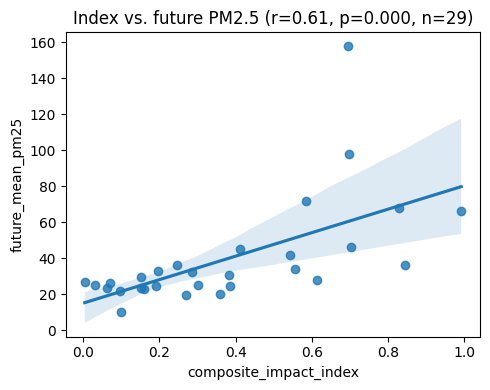

In [41]:
VALIDATION_SPLIT = 0.6
MIN_OBS_FOR_TREND_V = MIN_OBS_FOR_TREND

train_rows, future_rows = [], []
for city, grp in fused_df_clean.groupby('City'):
    grp = grp.dropna(subset=['ndvi', 'Datetime', target_col]).sort_values('Datetime')
    n_unique = grp['date_only'].nunique()
    if n_unique < MIN_OBS_FOR_TREND_V * 2:
        continue
    cutoff_idx = int(len(grp) * VALIDATION_SPLIT)
    train_rows.append(grp.iloc[:cutoff_idx])
    future_rows.append(grp.iloc[cutoff_idx:])

train_df_v = pd.concat(train_rows)
future_df_v = pd.concat(future_rows)

train_features_only = train_df_v[base_features + ['ndvi']].dropna()
train_target_only = train_df_v.loc[train_features_only.index, target_col]

rf_weights_train_only = RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1)
rf_weights_train_only.fit(train_features_only.values, train_target_only.values)

importances_train_only = pd.Series(rf_weights_train_only.feature_importances_, index=base_features + ['ndvi'])
w_veg_train = importances_train_only.get('ndvi', 0)
w_pol_train = importances_train_only.drop('ndvi', errors='ignore').sum()
total_w_train = w_veg_train + w_pol_train
w_vegetation_norm_v = w_veg_train / total_w_train
w_pollution_norm_v = w_pol_train / total_w_train

print(f"Weights from EARLY-PERIOD-ONLY data (no leakage): "
      f"vegetation={w_vegetation_norm_v:.3f}, pollution={w_pollution_norm_v:.3f}")
print(f"(Full-data weights for comparison: vegetation={w_vegetation_norm:.3f}, pollution={w_pollution_norm:.3f})")


def build_index_for_period(df_period, w_vegetation, w_pollution):
    rows = []
    for city, grp in df_period.groupby('City'):
        grp_unique_dates = grp.drop_duplicates(subset=['date_only'])
        if len(grp_unique_dates) < MIN_OBS_FOR_TREND_V:
            continue
        t = (grp_unique_dates['Datetime'] - grp_unique_dates['Datetime'].min()).dt.days.values
        slope, *_ = scipy_stats.linregress(t, grp_unique_dates['ndvi'].values)
        rows.append({'City': city, 'ndvi_slope': slope, 'mean_pm25': grp[target_col].mean()})
    out = pd.DataFrame(rows)
    out['vegetation_risk'] = min_max_norm(-out['ndvi_slope'])
    out['pollution_risk'] = min_max_norm(out['mean_pm25'])
    out['composite_impact_index'] = w_vegetation * out['vegetation_risk'] + w_pollution * out['pollution_risk']
    return out


index_train = build_index_for_period(train_df_v, w_vegetation_norm_v, w_pollution_norm_v)
future_outcome = future_df_v.groupby('City')[target_col].mean().rename('future_mean_pm25').reset_index()
validation_df = index_train.merge(future_outcome, on='City', how='inner')
n_cities_validated = len(validation_df)

corr, p_val = scipy_stats.pearsonr(validation_df['composite_impact_index'], validation_df['future_mean_pm25'])
print(f"\nCorrelation (index vs. actual future PM2.5): r = {corr:.3f}, p = {p_val:.4f}, n = {n_cities_validated} cities")

if n_cities_validated < 15:
    print(f"CAUTION: n={n_cities_validated} is small — state n alongside r and p whenever reporting this.")

if p_val < 0.05:
    print("Statistically significant. NOTE: given vegetation's near-zero weight, this mainly "
          "validates that a city's past PM2.5 predicts its future PM2.5, not that the "
          "vegetation component is doing meaningful work — say both parts explicitly.")
else:
    print("NOT statistically significant at this sample size — a legitimate finding, report it as such.")

plt.figure(figsize=(5, 4))
sns.regplot(data=validation_df, x='composite_impact_index', y='future_mean_pm25')
plt.title(f'Index vs. future PM2.5 (r={corr:.2f}, p={p_val:.3f}, n={n_cities_validated})')
plt.tight_layout()
plt.show()


## Results

| Pipeline | Result |
|---|---|
| Deforestation (MobileNetV2) | test AUC ~0.91-0.92, ~93% acc vs 90.5% baseline |
| PM2.5 forecast (XGBoost/NN) | R2 ~0.90-0.91 vs 0.0 baseline |
| Fusion ablation | R2 0.962 -> 0.972 with NDVI added |
| Composite index | r=0.61, p=0.0004, n=29 - mostly pollution-driven |

Caveats: fusion covers 29 cities/2022-2025 only, NH3 dropped, NDVI subsampled, index is
~99% pollution-weighted so the validation mostly shows PM2.5 autocorrelates over time
rather than vegetation adding predictive signal.
